# Project on AI Time Series Forecasting: Microsoft Corp. (MSFT) Stock Price
The prediction task is to estimate the daily adjusted closing price of Microsoft Corp. (MSFT) 
for the next business day (t+1) using the information available up to the current business day 
(t). The dataset includes equity-specific variables and macroeconomic indicators 
(commodities, market indices, and interest rates) that influence the US equity market. All 
variables are aggregated at a daily temporal resolution. 

## Step 1: Data Preprocessing
Requirements: 
* **Dataset:** Select a time-series dataset of your choice.  
* **Imputation:** Fill all missing values using the **K-Nearest Neighbors (KNN)** method.

In [133]:
import numpy as np 
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import pandasql as pdsql
%matplotlib inline

from sklearn.impute import KNNImputer 
from sklearn.preprocessing import RobustScaler

import warnings
warnings.filterwarnings("ignore")

import random
np.random.seed(42)
random.seed(42)


In [ ]:
# Path to my data 
data_path = "project/microsoft_corp/CaseStudy_MSFT.csv"

# Reading the data 
df = pd.read_csv(data_path, parse_dates=['date'])

# Adjust the index 
df = df.set_index('date')

# Adjust the column (time not needed, symbol is MSFT)
df = df.drop(columns=['time', 'symbol'])

# Display cleaned time series dataset
display(df.head())


,volume,adjprice,oil,gold,sp500,vix,rates_10y
date,,,,,,,
2010-01-04,38409100,23.077383,81.510002,1117.699951,1132.989990,20.040001,3.841
2010-01-05,49749600,23.084843,81.769997,1118.099976,1136.520020,19.350000,3.755
2010-01-06,58182400,22.943165,83.180000,1135.900024,1137.140015,19.160000,3.808
2010-01-07,50559700,22.704561,82.660004,1133.099976,1141.689941,19.059999,3.822
2010-01-08,51197400,22.861149,82.750000,1138.199951,1144.979980,18.129999,3.808


In [135]:
target_col = 'adjprice'

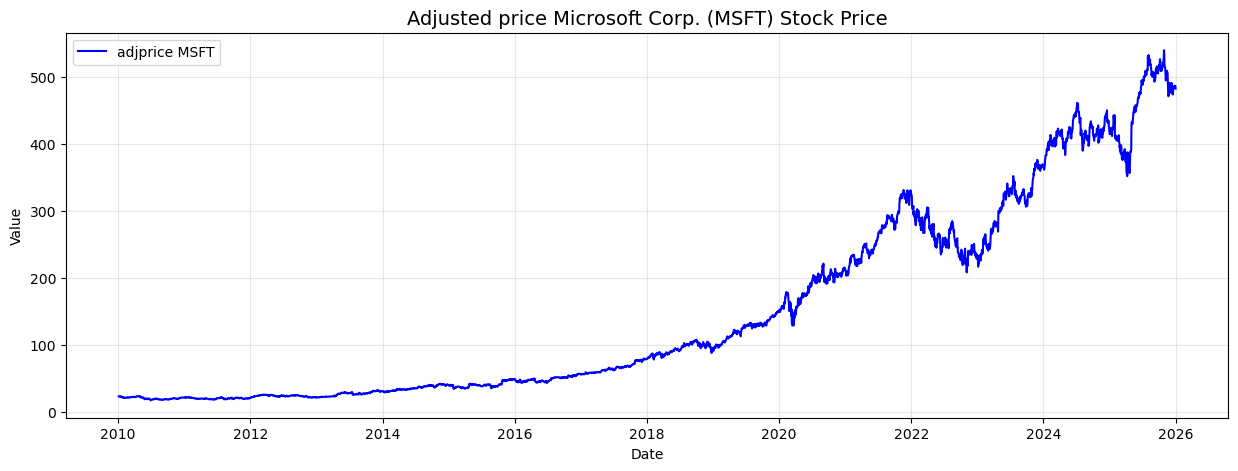

In [136]:
# Let's have a look at the data for the target column 
plt.figure(figsize=(15, 5))
plt.plot(df[target_col], label='adjprice MSFT', color='blue')
plt.title("Adjusted price Microsoft Corp. (MSFT) Stock Price", fontsize=14)
plt.ylabel("Value")
plt.xlabel("Date")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [137]:
# Discovering missing values 
# In the dataset, missing values are encoded as -999
# Replacing the value 
df = df.replace(-999, np.nan)

# Count the number of missing values per column 
df.isna().sum()

volume       0
adjprice     0
oil          2
gold         3
sp500        0
vix          0
rates_10y    2
dtype: int64

Splitting before making the imputation with KNN: avoiding data leakage problem.

In [138]:
# Year-based split boundaries 
# Train: 2010-2019 | Val: 2020-2022 | Test: 2023-2025 
TRAIN_END = '2019-12-31'
VAL_END = '2022-12-31'

# Split
train_raw = df[df.index <= TRAIN_END].copy()
val_raw = df[(df.index > TRAIN_END) & (df.index <= VAL_END)].copy()
test_raw = df[df.index > VAL_END].copy()

print(f"Train: {train_raw.index.min().date()} -> {train_raw.index.max().date()}  ({len(train_raw)} rows)")
print(f"Val:   {val_raw.index.min().date()} -> {val_raw.index.max().date()}  ({len(val_raw)} rows)")
print(f"Test:  {test_raw.index.min().date()} -> {test_raw.index.max().date()}  ({len(test_raw)} rows)")

# Missing values per each block: where are exactly the missing values for our problem? 
print("\nMissing values per split:")
print("TRAIN:\n", train_raw.isna().sum())
print("VAL:\n", val_raw.isna().sum())
print("TEST:\n", test_raw.isna().sum())

Train: 2010-01-04 -> 2019-12-31  (2516 rows)
Val:   2020-01-02 -> 2022-12-30  (756 rows)
Test:  2023-01-03 -> 2025-12-31  (752 rows)

Missing values per split:
TRAIN:
 volume       0
adjprice     0
oil          2
gold         3
sp500        0
vix          0
rates_10y    2
dtype: int64
VAL:
 volume       0
adjprice     0
oil          0
gold         0
sp500        0
vix          0
rates_10y    0
dtype: int64
TEST:
 volume       0
adjprice     0
oil          0
gold         0
sp500        0
vix          0
rates_10y    0
dtype: int64


All the missing values are in the train set, so it makes sense imputing the values inside the training set space, not in the entire space of the feature considering also the validation and the test feature space.  

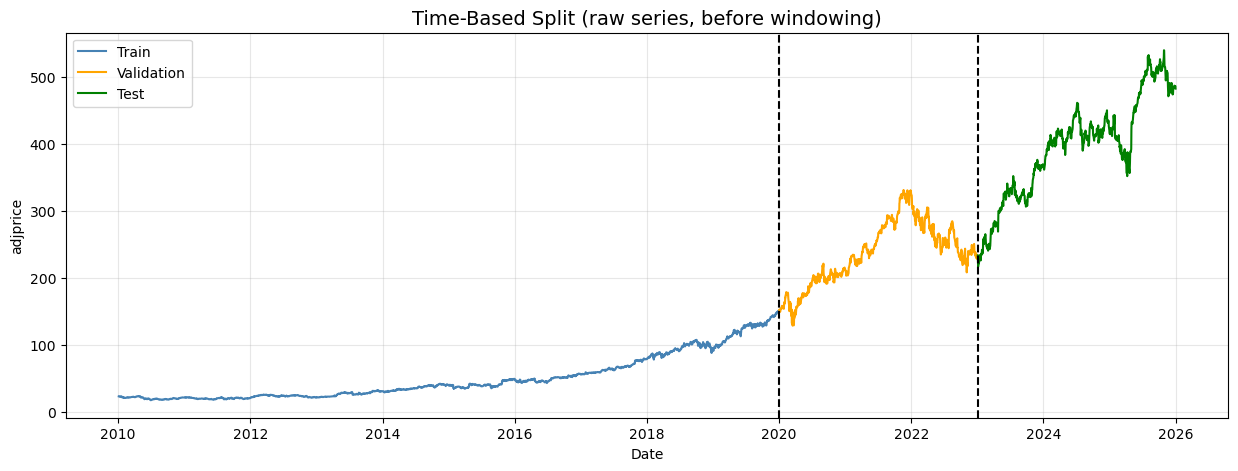

In [139]:
plt.figure(figsize=(15, 5))
plt.plot(train_raw.index, train_raw[target_col], label='Train', color='steelblue')
plt.plot(val_raw.index, val_raw[target_col], label='Validation', color='orange')
plt.plot(test_raw.index, test_raw[target_col], label='Test', color='green')
plt.axvline(val_raw.index[0], color='black', linestyle='--')
plt.axvline(test_raw.index[0], color='black', linestyle='--')
plt.title("Time-Based Split (raw series, before windowing)", fontsize=14)
plt.ylabel("adjprice")
plt.xlabel("Date")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [140]:
# Since missing values are very few, we can impute them with the KNN 
knn_imputer = KNNImputer(n_neighbors=5)

# Fit and trasform 
knn_data_train = knn_imputer.fit_transform(train_raw)

# Restore the dataframe 
train_raw_knn = pd.DataFrame(knn_data_train, index=train_raw.index, columns=train_raw.columns)

# New missing values 
train_raw_knn.isna().sum()

volume       0
adjprice     0
oil          0
gold         0
sp500        0
vix          0
rates_10y    0
dtype: int64

In this case we are making an assumption: we are using KNN in the entire feature space, without considering the fact that different feature are based on different scale.

In [141]:
train_raw_knn.describe()

,volume,adjprice,oil,gold,sp500,vix,rates_10y
count,2.516000e+03,2516.000000,2516.000000,2516.000000,2516.000000,2516.000000,2516.000000
mean,3.992631e+07,49.719300,72.516204,1346.853983,1962.608854,16.858871,2.395436
std,2.299181e+07,33.348352,21.899011,179.020100,588.910251,5.630784,0.552701
min,7.425600e+06,17.315042,26.209999,1050.800049,1022.580017,9.140000,1.366000
25%,2.429422e+07,23.123494,52.410000,1224.500000,1384.404999,13.047500,1.954750
50%,3.424585e+07,38.077637,71.349998,1293.400024,1986.479980,15.470000,2.343000
75%,4.978198e+07,64.428165,93.532499,1435.300049,2433.967529,18.900000,2.755000
max,3.193179e+08,150.585846,113.930000,1888.699951,3240.020020,48.000000,3.994000


We can see that the features have different standard deviations between them, so it makes sense fit the imputer on a scaled space, then restore the original feature space. `RobustScaler()`is selected as it is a suitable option in order to take into account the outlier of the price of the oil in the pandemic window. 

In [142]:
# Used robust scaler to make the KNN imputation
robust_scaler = RobustScaler()
train_scaled = robust_scaler.fit_transform(train_raw)  
train_scaled_imputed = KNNImputer(n_neighbors=5).fit_transform(train_scaled)
train_robust = pd.DataFrame(
    robust_scaler.inverse_transform(train_scaled_imputed),
    index=train_raw.index, columns=train_raw.columns
)

In [143]:
# Quick comparison 
missing_mask = train_raw.isna()
comparison = pd.DataFrame({
    'unscaled': train_raw_knn[missing_mask].stack(),
    'robust_scaled': train_robust[missing_mask].stack(),
})
comparison['difference'] = comparison['robust_scaled'] - comparison['unscaled']
print(comparison)

                         unscaled  robust_scaled  difference
date                                                        
2010-10-11 rates_10y     2.386400       3.213800    0.827400
2016-10-10 oil          62.439999      49.516000  -12.923999
           gold       1231.680005    1267.840015   36.160010
2016-11-11 oil          96.789999      45.702000  -51.088000
           gold       1520.780005    1183.140015 -337.639990
           rates_10y     2.386200       2.104400   -0.281800
2018-01-29 gold       1242.960010    1315.080005   72.119995


In [144]:
# Concatenating the dataset 
train_imputed = train_robust

data = pd.concat([train_imputed, val_raw, test_raw]).sort_index()

print(f"Shape of the final dataset: {data.shape}")
print(f"Missing values: {data.isna().sum().sum()}")

Shape of the final dataset: (4024, 7)
Missing values: 0


In [145]:
# Check types
data.dtypes

volume       float64
adjprice     float64
oil          float64
gold         float64
sp500        float64
vix          float64
rates_10y    float64
dtype: object

In [146]:
# Check distributions and values 
data.describe()

,volume,adjprice,oil,gold,sp500,vix,rates_10y
count,4.024000e+03,4024.000000,4024.000000,4024.000000,4024.000000,4024.000000,4024.000000
mean,3.529555e+07,149.293493,71.532062,1663.167211,2945.011381,18.412875,2.604174
std,2.058245e+07,145.119517,20.799435,584.726810,1491.073720,6.873274,1.004028
min,5.855900e+06,17.315042,-37.630001,1050.800049,1022.580017,9.140000,0.499000
25%,2.192250e+07,30.767126,54.167499,1268.475006,1805.630035,13.770000,1.853000
50%,2.938710e+07,78.815315,71.555000,1505.700012,2584.730103,16.660000,2.458500
75%,4.318792e+07,250.818756,88.265001,1830.049988,4078.204956,21.100000,3.334750
max,3.193179e+08,539.825256,123.699997,4529.100098,6932.049805,82.690002,4.988000


In [147]:
# Check a negative value resulted from .describe() method 
def negative_numbers(dataset, target_column):
    return (dataset[target_column] < 0).sum()

print(negative_numbers(data,'oil'))

1


In [148]:
# Extracting the row where oil price is negative 
data[data['oil'] < 0]

,volume,adjprice,oil,gold,sp500,vix,rates_10y
date,,,,,,,
2020-04-20,36669600.0,166.290649,-37.630001,1701.599976,2823.159912,43.830002,0.626


In [149]:
# Use of pandas sql to be able to do some simple queries in the dataset  
# Query 1: extract all the rows of the dataset near the negative oil price
# Key point 1: each row is related the days in which the stock market is open, 
# that's why we don't have data on 2020-04-18 and 2020-04-19, like all the other
# rows where the stock market is closed on the weekend. 
query = ''' select date, oil
            from data
            where date between '2020-04-15%' and '2020-04-25'
        '''
pdsql.sqldf(query)

,date,oil
0,2020-04-16 00:00:00.000000,19.870001
1,2020-04-17 00:00:00.000000,18.270000
2,2020-04-20 00:00:00.000000,-37.630001
3,2020-04-21 00:00:00.000000,10.010000
4,2020-04-22 00:00:00.000000,13.780000
5,2020-04-23 00:00:00.000000,16.500000
6,2020-04-24 00:00:00.000000,16.940001


In [150]:
# Query 2: retrieving the minimum absolute price higher than 0 
query = ''' 
        select min(oil) as abs_min_positive_oil
        from data
        where oil >= 0 
        '''
pdsql.sqldf(query)

,abs_min_positive_oil
0,10.01


In [151]:
# Checking for duplicates rows 
print(f"Lenght of the dataset before dropping duplicated rows: {len(data)}")
print(f"Lenght of the dataset after dropping duplicated rows: {len(data.drop_duplicates())}")

Lenght of the dataset before dropping duplicated rows: 4024
Lenght of the dataset after dropping duplicated rows: 4024


## EDA

This step is needed to have a look at the data as done for the train - val - test splitting. 

In [152]:
# First value (since data are ordered)
data.index[0]

Timestamp('2010-01-04 00:00:00')

In [153]:
# Last value (since data are ordered)
data.index[-1]

Timestamp('2025-12-31 00:00:00')

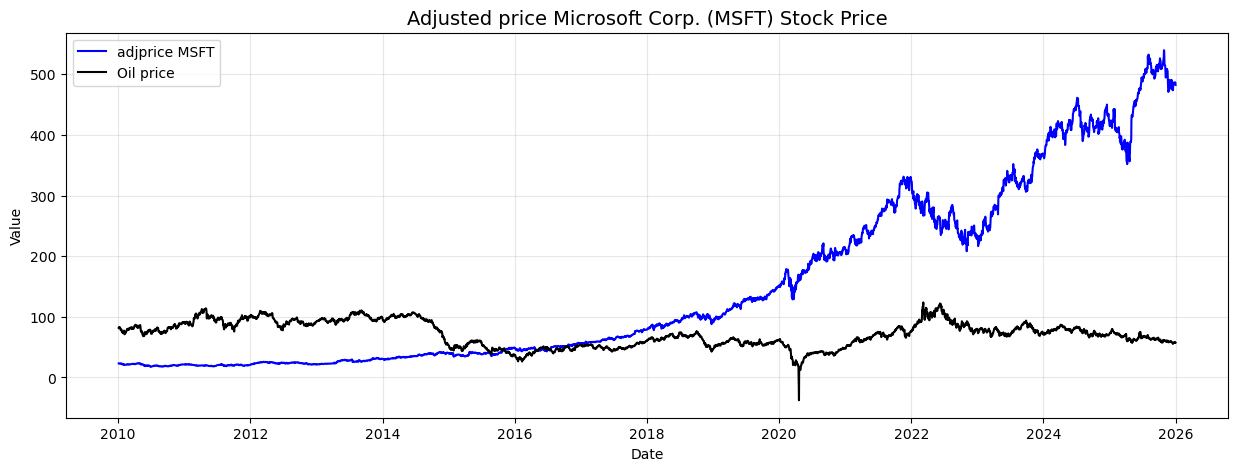

In [154]:
# Let's have a look at the data of MSFT price and Oil Price combined 
plt.figure(figsize=(15, 5))
plt.plot(data[target_col], label='adjprice MSFT', color='blue')
plt.plot(data['oil'], label='Oil price', color='black')
plt.title("Adjusted price Microsoft Corp. (MSFT) Stock Price", fontsize=14)
plt.ylabel("Value")
plt.xlabel("Date")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

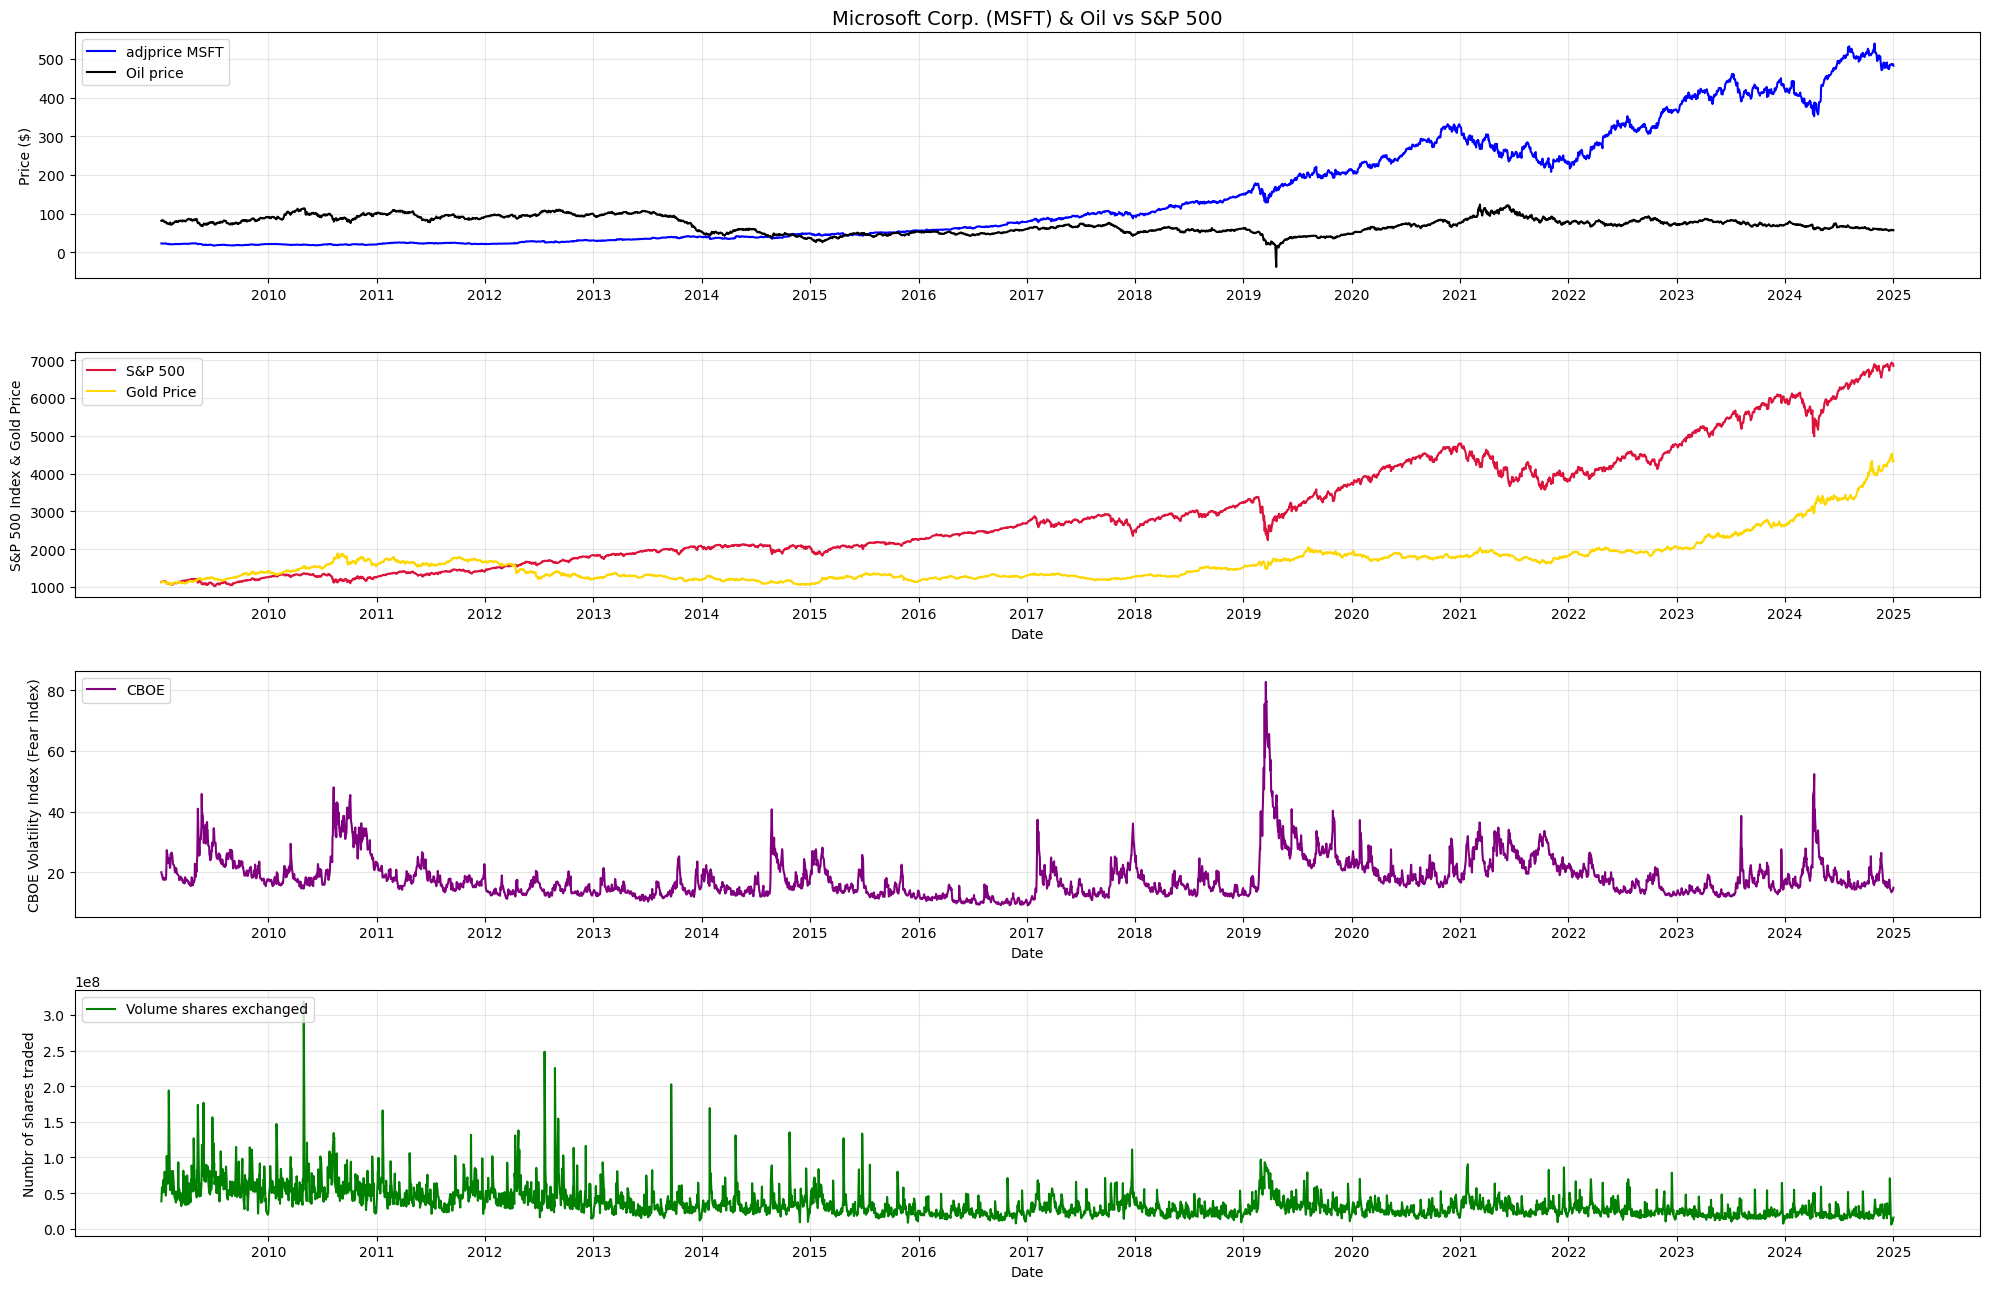

In [155]:
# Connection of figures describing the relationship netween different y values (our features in the dataset) and time (index in the dataset)
fig, (ax1, ax2, ax3, ax4) = plt.subplots(
    4, 1, figsize=(20, 13), gridspec_kw={"height_ratios": [1, 1, 1, 1]}
)

# Putting the xticks in years
tick = pd.date_range(start="2010-01-01", end="2025-12-31", freq="Y")
years = [d.strftime("%Y") for d in tick]

# First plot 
ax1.plot(data[target_col], label="adjprice MSFT", color="blue")
ax1.plot(data["oil"], label="Oil price", color="black")
ax1.set_title("Microsoft Corp. (MSFT) & Oil vs S&P 500", fontsize=14)
ax1.set_ylabel("Price ($)")
ax1.legend(loc="upper left")
ax1.grid(True, alpha=0.3)
ax1.set_xticks(tick)
ax1.set_xticklabels(years)

# Second plot 
ax2.plot(data["sp500"], label="S&P 500", color="crimson")
ax2.plot(data["gold"], label="Gold Price", color="gold")
ax2.set_ylabel("S&P 500 Index & Gold Price")
ax2.set_xlabel("Date")
ax2.legend(loc="upper left")
ax2.grid(True, alpha=0.3)
ax2.set_xticks(tick)
ax2.set_xticklabels(years)

# Third plot 
ax3.plot(data["vix"], label="CBOE", color="purple")
ax3.set_ylabel("CBOE Volatility Index (Fear Index)")
ax3.set_xlabel("Date")
ax3.legend(loc="upper left")
ax3.grid(True, alpha=0.3)
ax3.set_xticks(tick)
ax3.set_xticklabels(years)

# Fourth plot 
ax4.plot(data["volume"], label="Volume shares exchanged", color="green")
ax4.set_ylabel("Numbr of shares traded")
ax4.set_xlabel("Date")
ax4.legend(loc="upper left")
ax4.grid(True, alpha=0.3)
ax4.set_xticks(tick)
ax4.set_xticklabels(years)

plt.tight_layout()
plt.show()

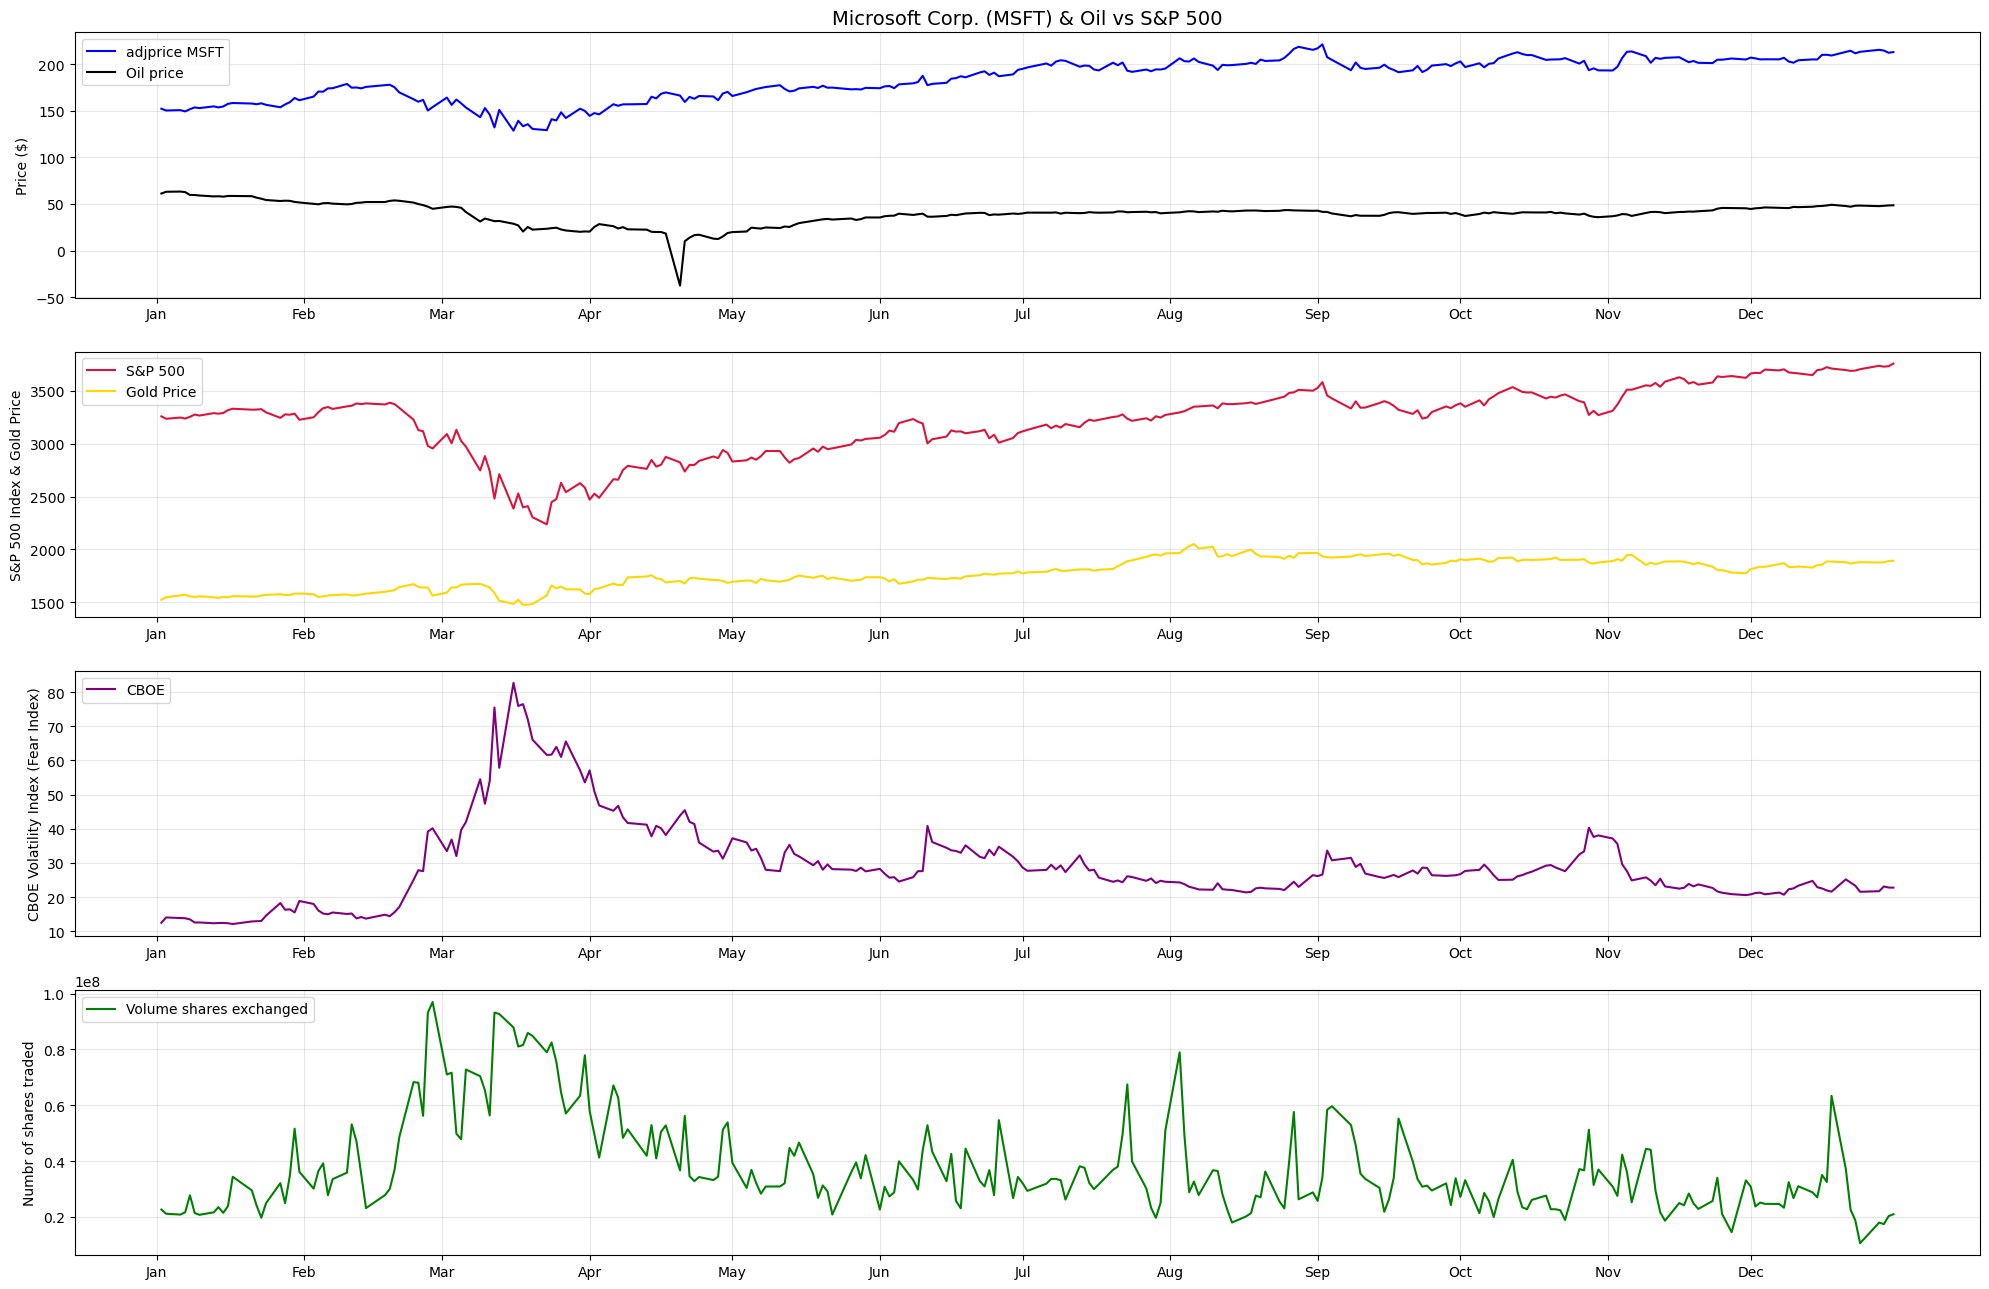

In [156]:
# Connection of figures describing the relationship netween different y values (our features in the dataset) and time (index in the dataset)
fig, (ax1, ax2, ax3, ax4) = plt.subplots(
    4, 1, figsize=(20, 13), gridspec_kw={"height_ratios": [1, 1, 1, 1]}
)

# Extract only data from 2020
data_2020 = data[data.index.year == 2020]

# Putting the xticks in months
tick = pd.date_range(start="2020-01-01", end="2020-12-01", freq="MS")
months = [d.strftime("%b") for d in tick]

# First plot 
ax1.plot(data_2020[target_col], label="adjprice MSFT", color="blue")
ax1.plot(data_2020["oil"], label="Oil price", color="black")
ax1.set_title("Microsoft Corp. (MSFT) & Oil vs S&P 500", fontsize=14)
ax1.set_ylabel("Price ($)")
ax1.legend(loc="upper left")
ax1.grid(True, alpha=0.3)
ax1.set_xticks(tick)
ax1.set_xticklabels(months)

# Second plot 
ax2.plot(data_2020["sp500"], label="S&P 500", color="crimson")
ax2.plot(data_2020["gold"], label="Gold Price", color="gold")
ax2.set_ylabel("S&P 500 Index & Gold Price")
ax2.legend(loc="upper left")
ax2.grid(True, alpha=0.3)
ax2.set_xticks(tick)
ax2.set_xticklabels(months)

# Third plot 
ax3.plot(data_2020["vix"], label="CBOE", color="purple")
ax3.set_ylabel("CBOE Volatility Index (Fear Index)")
ax3.legend(loc="upper left")
ax3.grid(True, alpha=0.3)
ax3.set_xticks(tick)
ax3.set_xticklabels(months)

# Fourth plot 
ax4.plot(data_2020["volume"], label="Volume shares exchanged", color="green")
ax4.set_ylabel("Numbr of shares traded")
ax4.legend(loc="upper left")
ax4.grid(True, alpha=0.3)
ax4.set_xticks(tick)
ax4.set_xticklabels(months)

plt.tight_layout()
plt.show()

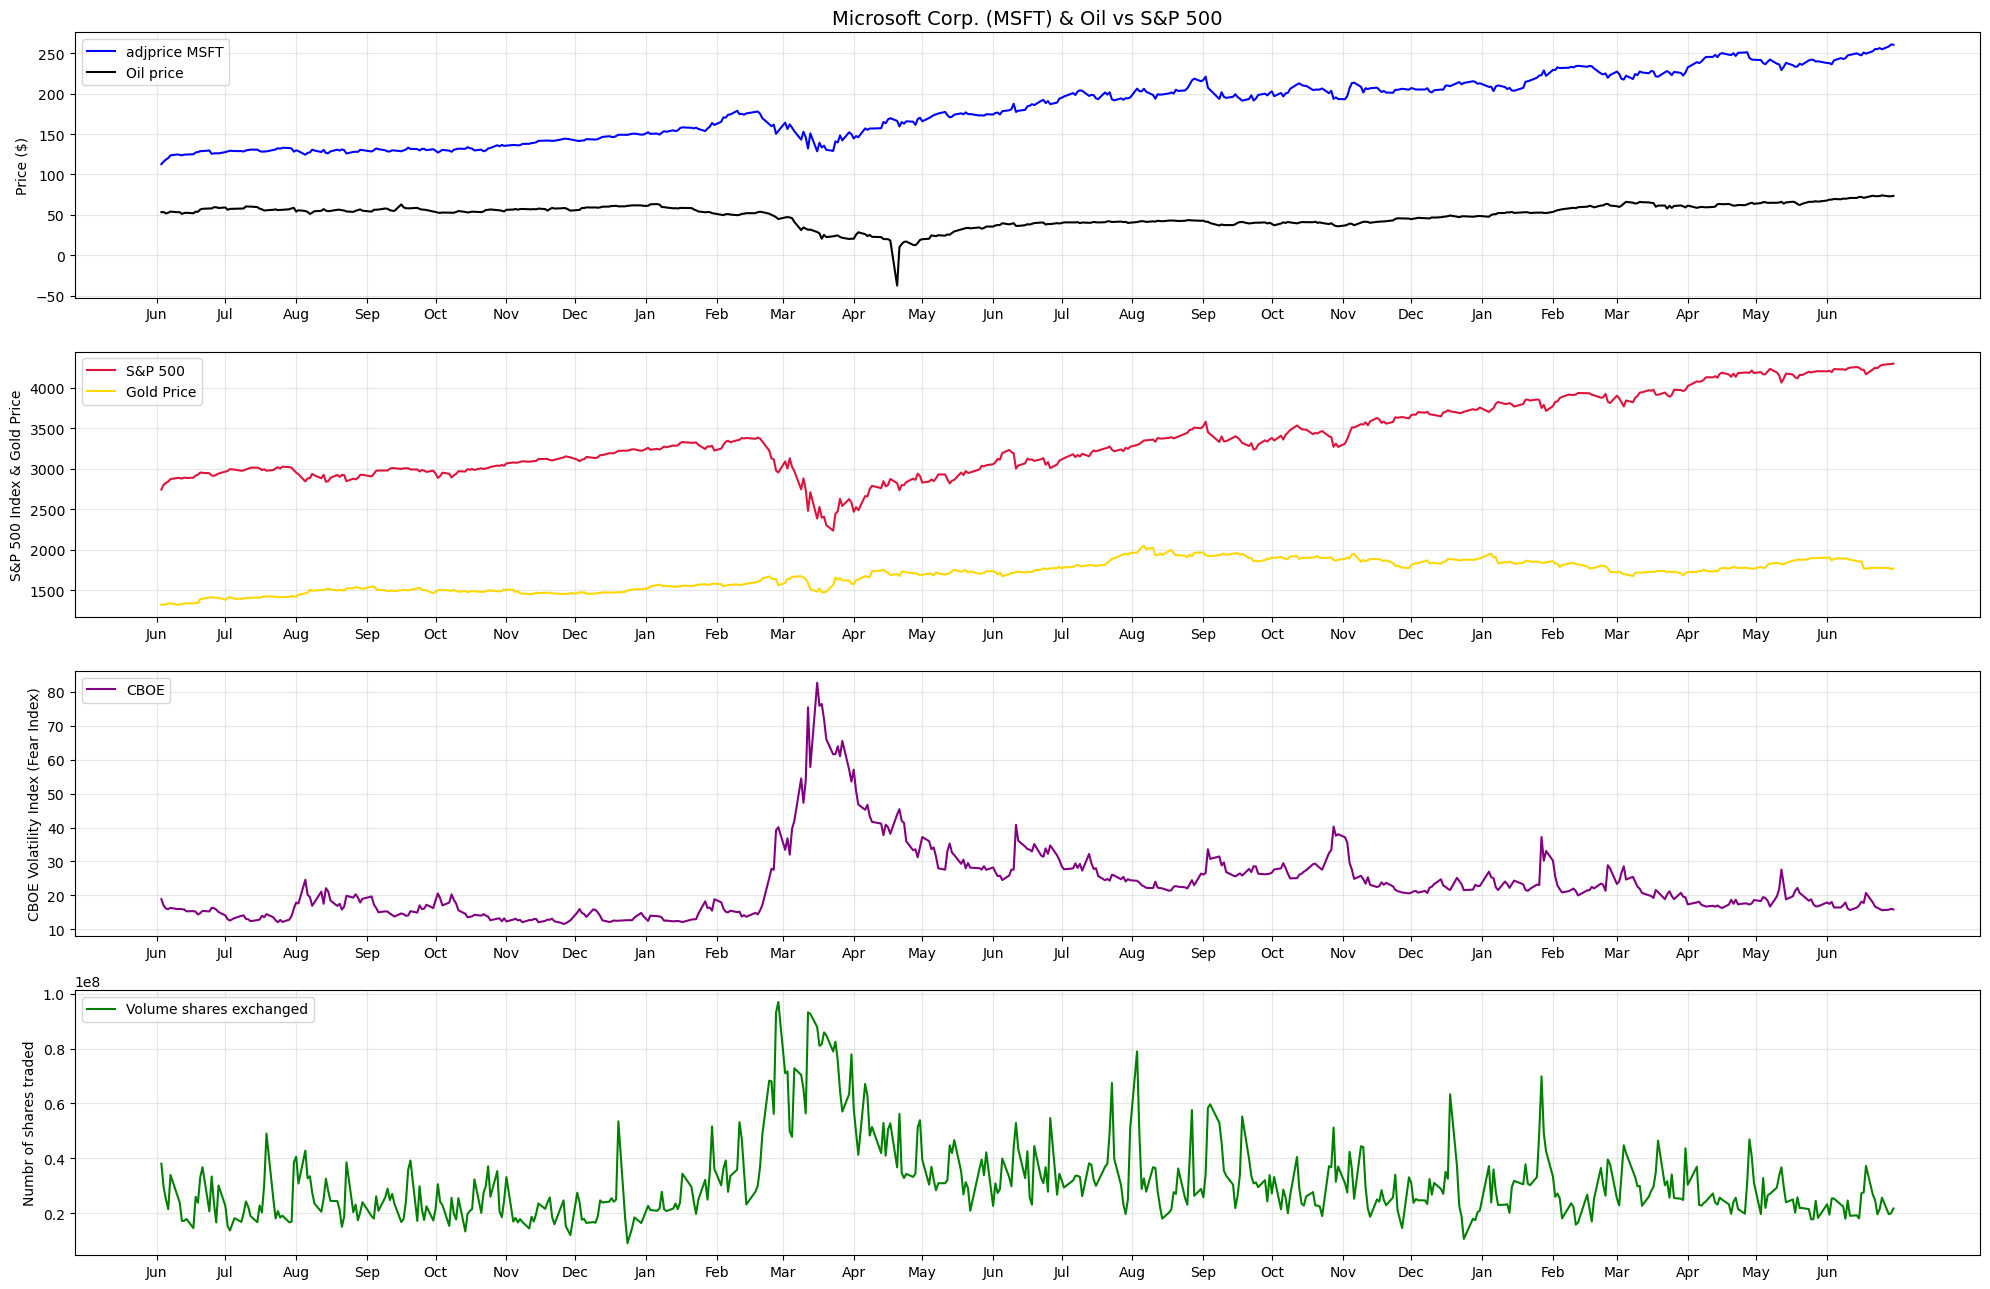

In [157]:
# Connection of figures describing the relationship netween different y values (our features in the dataset) and time (index in the dataset)
fig, (ax1, ax2, ax3, ax4) = plt.subplots(
    4, 1, figsize=(20, 13), gridspec_kw={"height_ratios": [1, 1, 1, 1]}
)

# Extract only data from a different interval 
data_filtered = data.loc["2019-06-01":"2021-06-30"]

# Putting the xticks in months
tick = pd.date_range(start="2019-06-01", end="2021-06-01", freq="MS")
months = [d.strftime("%b") for d in tick]

# First plot 
ax1.plot(data_filtered[target_col], label="adjprice MSFT", color="blue")
ax1.plot(data_filtered["oil"], label="Oil price", color="black")
ax1.set_title("Microsoft Corp. (MSFT) & Oil vs S&P 500", fontsize=14)
ax1.set_ylabel("Price ($)")
ax1.legend(loc="upper left")
ax1.grid(True, alpha=0.3)
ax1.set_xticks(tick)
ax1.set_xticklabels(months)

# Second plot 
ax2.plot(data_filtered["sp500"], label="S&P 500", color="crimson")
ax2.plot(data_filtered["gold"], label="Gold Price", color="gold")
ax2.set_ylabel("S&P 500 Index & Gold Price")
ax2.legend(loc="upper left")
ax2.grid(True, alpha=0.3)
ax2.set_xticks(tick)
ax2.set_xticklabels(months)

# Third plot 
ax3.plot(data_filtered["vix"], label="CBOE", color="purple")
ax3.set_ylabel("CBOE Volatility Index (Fear Index)")
ax3.legend(loc="upper left")
ax3.grid(True, alpha=0.3)
ax3.set_xticks(tick)
ax3.set_xticklabels(months)

# Fourth plot 
ax4.plot(data_filtered["volume"], label="Volume shares exchanged", color="green")
ax4.set_ylabel("Numbr of shares traded")
ax4.legend(loc="upper left")
ax4.grid(True, alpha=0.3)
ax4.set_xticks(tick)
ax4.set_xticklabels(months)

plt.tight_layout()
plt.show()

## Saving the data

In [158]:
# data.to_csv('/Users/marcobiondi/Desktop/project_AI_time_series/project/microsoft_corp/data_clean.csv')
print(f"Saved: {data.shape[0]} rows, {data.shape[1]} columns, 0 missing")

Saved: 4024 rows, 7 columns, 0 missing


## Forecasting problem 

We set up the key parameters for a forecasting problem 

In [159]:
# window_size (d): Number of past days used as input
# We choose 7 days to capture a full weekly cycle
window_size = 7 # to be changed in future developments 

# lead_time (h): How many steps ahead to predict
# The task asks (t+1) so the very next business day 
lead_time = 1

print(f"Problem Setup:")
print(f"Target variable: {target_col}")
print(f"Input: Past {window_size} days of data")
print(f"Output: Predict the value {lead_time} day(s) into the future")

Problem Setup:
Target variable: adjprice
Input: Past 7 days of data
Output: Predict the value 1 day(s) into the future


## Dataset building 

In [160]:
def create_dataset(series, window_size, lead_time):
    """
    Converts a time series into a supervised learning format.

    Parameters:
    - series: The input time series (Pandas Series or Numpy array)
    - window_size: The number of past steps to look at (d)
    - lead_time: How many steps into the future to predict (h)

    Returns:
    - X: Numpy array of shape (n_samples, window_size)
    - y: Numpy array of shape (n_samples,)
    """
    X, y = [], []

    # Ensure data is in numpy format for easier indexing
    if isinstance(series, pd.Series) or isinstance(series, pd.DataFrame):
        data = series.values
    else:
        data = series

    # We loop through the data, stopping before we run out of future values to predict
    for i in range(len(data) - window_size - lead_time + 1):
        # Input: sequence from i to i + window_size
        X.append(data[i : i + window_size])

        # Output: the value at lead_time steps after the window ends
        y.append(data[i + window_size + lead_time - 1])

    return np.array(X), np.array(y)

In [161]:
# Create the dataset using the parameters and the function defined 
X, y = create_dataset(data[target_col], window_size=window_size, lead_time=lead_time)

print("Dataset Construction Complete.")
print(f"Shape of X: {X.shape}  -> (n_samples, window_size)")
print(f"Shape of y: {y.shape}      -> (n_samples,)")

Dataset Construction Complete.
Shape of X: (4017, 7)  -> (n_samples, window_size)
Shape of y: (4017,)      -> (n_samples,)


In [162]:
# Check if all is correct 
print("--- Example Sample (First Row) ---")
print(f"Input (Past {window_size} days):")
print(X[0])
print(f"\nTarget (The value to predict):")
print(y[0])

# Verification with the original dataframe
print("\n--- Original Data Verification ---")
print(data[target_col].head(window_size + 1))

--- Example Sample (First Row) ---
Input (Past 7 days):
[23.07738304 23.08484268 22.94316483 22.70456123 22.86114883 22.57035446
 22.42122459]

Target (The value to predict):
22.63000106811523

--- Original Data Verification ---
date
2010-01-04    23.077383
2010-01-05    23.084843
2010-01-06    22.943165
2010-01-07    22.704561
2010-01-08    22.861149
2010-01-11    22.570354
2010-01-12    22.421225
2010-01-13    22.630001
Name: adjprice, dtype: float64


## Splitting the data 

In [163]:
# As before, we take until 2019 for training, until 2022 for validation and then until 2026 for test
y_dates = data.index[window_size + lead_time - 1:]
train_end_idx = np.where(y_dates.year <= 2019)[0][-1] + 1
val_end_idx = np.where(y_dates.year <= 2022)[0][-1] + 1

X_train, y_train = X[:train_end_idx], y[:train_end_idx]
X_val, y_val = X[train_end_idx:val_end_idx], y[train_end_idx:val_end_idx]
X_test, y_test = X[val_end_idx:], y[val_end_idx:]

print(f"Train: {y_dates[0].date()} -> {y_dates[train_end_idx-1].date()}  ({len(X_train)}) ({round(len(X_train)/len(data)*100)}%)")
print(f"Val:   {y_dates[train_end_idx].date()} -> {y_dates[val_end_idx-1].date()}  ({len(X_val)}) ({round(len(X_val)/len(data)*100)}%)")
print(f"Test:  {y_dates[val_end_idx].date()} -> {y_dates[-1].date()}  ({len(X_test)}) ({round(len(X_test)/len(data)*100)}%)")

Train: 2010-01-13 -> 2019-12-31  (2509) (62%)
Val:   2020-01-02 -> 2022-12-30  (756) (19%)
Test:  2023-01-03 -> 2025-12-31  (752) (19%)


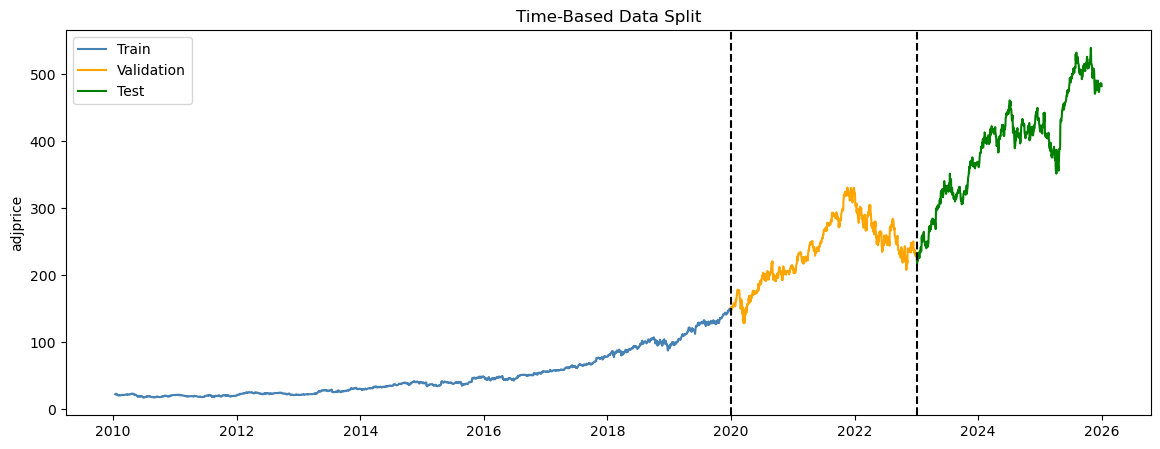

In [164]:
# Check again the split 
plt.figure(figsize=(14, 5))
dates = data.index[window_size + lead_time - 1:]
plt.plot(dates[:train_end_idx], y_train, label='Train', color='steelblue')
plt.plot(dates[train_end_idx:val_end_idx], y_val, label='Validation', color='orange')
plt.plot(dates[val_end_idx:], y_test, label='Test', color='green')
plt.axvline(dates[train_end_idx], color='black', linestyle='--')
plt.axvline(dates[val_end_idx], color='black', linestyle='--')
plt.title("Time-Based Data Split")
plt.ylabel("adjprice")
plt.legend()
plt.show()